# Backtest report — Avellaneda-Stoikov vs Baseline vs Microprice

Стратегии:
1. `BaselineStrategy` — фикс. спред вокруг mid (sanity check, без inventory control)
2. `AvellanedaStoikov2008` — оптимальный MM по AS-2008
3. `make_microprice_strategy` — AS-2008 с fair price = microprice (Stoikov 2018)


In [1]:
!pip install matplotlib

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import EngineConfig, StrategyConfig, PRICE_SCALE
from src.reader import stream_events
from src.engine import BacktestEngine
from src.strategies import (
    BaselineStrategy, AvellanedaStoikov2008, make_microprice_strategy,
)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Подготовка: σ из mid-price returns

In [3]:
DATA = ROOT / 'data' / 'MD' / 'sample'
LOB_PATH = str(DATA / 'lob.csv')
TRD_PATH = str(DATA / 'trades.csv')

df_lob = pd.read_csv(LOB_PATH)
df_lob['mid'] = (df_lob['asks[0].price'] + df_lob['bids[0].price']) / 2
df_lob['mid_fp'] = (df_lob['mid'] * PRICE_SCALE).round().astype(np.int64)

dmid = np.diff(df_lob['mid_fp'].values).astype(np.float64)
dt_us = np.diff(df_lob['local_timestamp'].values)
mask = dt_us > 0
SIGMA_FP = float(np.sqrt(np.mean((dmid[mask]**2)/dt_us[mask])) * np.sqrt(1e6))

print(f'LOB snapshots: {len(df_lob):,}')
print(f'Period: {(df_lob["local_timestamp"].iloc[-1] - df_lob["local_timestamp"].iloc[0]) / 1e6 / 60:.1f} min')
print(f'Mid: {df_lob["mid"].min():.6f} → {df_lob["mid"].max():.6f}  (Δ={(df_lob["mid"].iloc[-1] - df_lob["mid"].iloc[0])/df_lob["mid"].iloc[0]*100:+.2f}%)')
print(f'σ = {SIGMA_FP:.4f} fp/√s')

LOB snapshots: 7,196
Period: 60.0 min
Mid: 0.010981 → 0.011124  (Δ=+0.63%)
σ = 18.1828 fp/√s


/var/folders/1z/jh0zg66d37xcb0r5t1ps6s_h0000gn/T/ipykernel_64733/418253477.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lob['mid'] = (df_lob['asks[0].price'] + df_lob['bids[0].price']) / 2
/var/folders/1z/jh0zg66d37xcb0r5t1ps6s_h0000gn/T/ipykernel_64733/418253477.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_lob['mid_fp'] = (df_lob['mid'] * PRICE_SCALE).round().astype(np.int64)


---
## 1. Первое сравнение: baseline vs AS vs microprice

In [4]:
def run(strategy):
    engine = BacktestEngine(strategy=strategy, cfg=EngineConfig())
    return engine.run(stream_events(LOB_PATH, TRD_PATH))

def stats(name, m):
    s = m.summary()
    pnl = np.array(m.pnl_log); inv = np.array(m.inv_log)
    d = np.diff(pnl) if len(pnl) > 1 else np.array([0.0])
    return {
        'strategy':  name,
        'PnL':       s['final_pnl'],
        'std(inv)':  float(inv.std()),
        'std(dPnL)': float(d.std()),
        'max_dd':    float((pnl - np.maximum.accumulate(pnl)).min()),
        'final_inv': s['final_inventory'],
        'fills':     s['n_fills'],
    }

cfg0 = StrategyConfig(gamma=0.1, k=1.5, sigma=SIGMA_FP, T=0.1,
                      order_size=1000.0, max_inventory=20.0)

results0 = {
    'baseline':   run(BaselineStrategy(half_spread_fp=2, size=1000.0)),
    'as2008':     run(AvellanedaStoikov2008(cfg0)),
    'microprice': run(make_microprice_strategy(cfg0)),
}

initial = pd.DataFrame([stats(n, m) for n, m in results0.items()])
initial

,strategy,PnL,std(inv),std(dPnL),max_dd,final_inv,fills
0,baseline,-10.347882,51350.985731,0.224304,-19.480424,-182144.0,3778
1,as2008,-3.795846,1372.026308,0.003351,-3.795746,2061.0,4332
2,microprice,-3.720684,1379.572776,0.003243,-3.720484,1871.0,4387


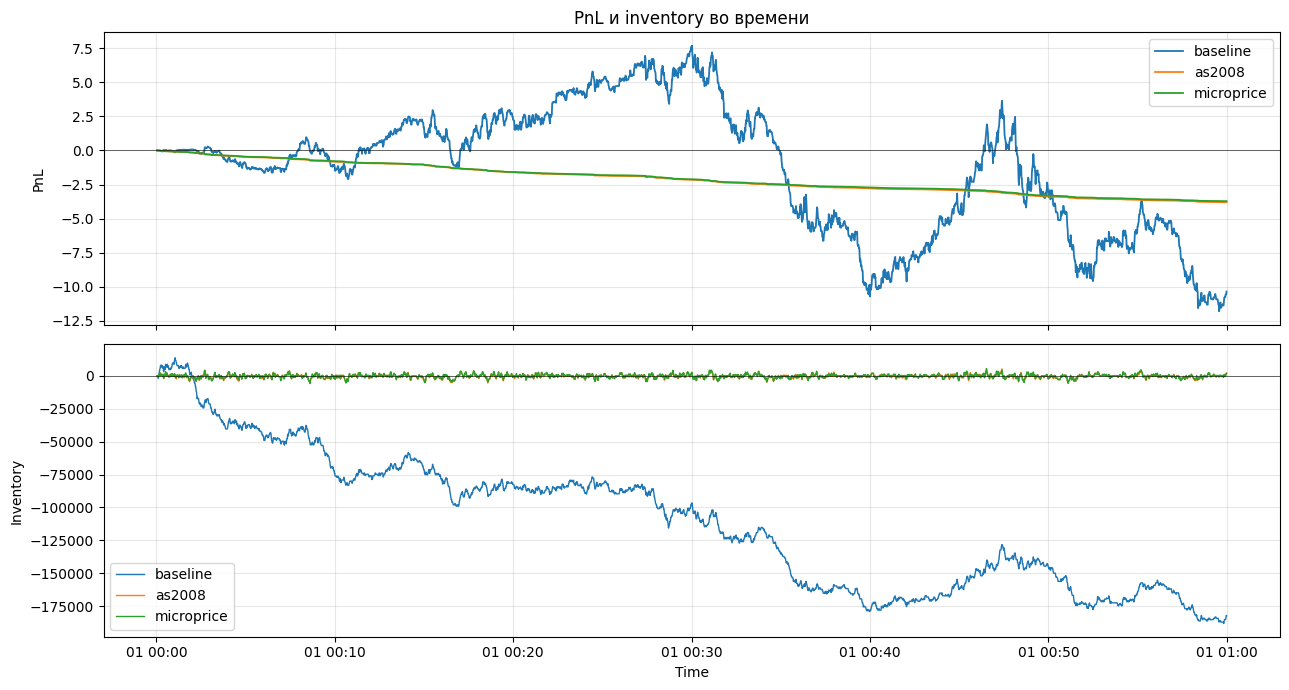

In [5]:
def to_df(m):
    return pd.DataFrame({
        'pnl': m.pnl_log, 'inventory': m.inv_log, 'mid': m.mid_log,
    }, index=pd.to_datetime(m.ts_log, unit='us'))

dfs0 = {n: to_df(m) for n, m in results0.items()}
colors = {'baseline': 'tab:blue', 'as2008': 'tab:orange', 'microprice': 'tab:green'}

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for n, df in dfs0.items():
    axes[0].plot(df.index, df['pnl'], label=n, color=colors[n], lw=1.3)
    axes[1].plot(df.index, df['inventory'], label=n, color=colors[n], lw=1.0)
axes[0].set_title('PnL и inventory во времени')
axes[0].set_ylabel('PnL'); axes[0].legend(); axes[0].axhline(0, color='black', lw=0.4)
axes[1].set_ylabel('Inventory'); axes[1].legend(); axes[1].axhline(0, color='black', lw=0.4)
axes[1].set_xlabel('Time')
plt.tight_layout(); plt.show()

**Что видно по PnL:** PnL у baseline сильно скачет в зависимости от промежутка на котором мы рассматриваем котировку монеты, у AS и microprice идёт почти ровной линией.

AS и microprice держат inventory у нуля -> у них PnL не зависит от направления, только от спреда.

PnL = (cash от спреда) + (inventory * dprice). У baseline доминирует второе слагаемое - direction-driven, не market-making.

---
## 2. Декомпозиция PnL: спред vs направление

Посчитаем "честный" заработок от market-making - тот что не зависит от направления:

In [6]:
for name, m in results0.items():
    s = m.summary()
    pnl = s['final_pnl']
    cash = s['final_cash']
    inv = s['final_inventory']
    mid = s['final_mid']
    direction_pnl = inv * mid       # сколько от направления
    spread_pnl = cash               # cash от спреда (грубо)
    print(f'{name:>11}: PnL={pnl:+9.2f} = spread≈{cash:+9.2f}  +  direction≈{inv*mid:+9.2f}')

   baseline: PnL=   -10.35 = spread≈ +2014.44  +  direction≈ -2024.79
     as2008: PnL=    -3.80 = spread≈   -26.71  +  direction≈   +22.91
 microprice: PnL=    -3.72 = spread≈   -24.52  +  direction≈   +20.80


Видно прямо в декомпозиции — у baseline PnL это почти полностью **direction**, у AS и microprice **direction ≈ 0** потому что inventory жёстко контролируется.

В случайной выборке half of the time направление помогло бы, half — навредило. Sharpe-ratio покажет правильную картину:

In [7]:
def with_sharpe(name, m):
    s = stats(name, m)
    pnl = np.array(m.pnl_log)
    d = np.diff(pnl) if len(pnl) > 1 else np.array([0.0])
    s['sharpe'] = (d.mean() / d.std() * np.sqrt(len(d))) if d.std() > 0 else 0.0
    return s

initial_full = pd.DataFrame([with_sharpe(n, m) for n, m in results0.items()])
initial_full[['strategy', 'PnL', 'sharpe', 'std(inv)', 'std(dPnL)', 'max_dd', 'fills']]

,strategy,PnL,sharpe,std(inv),std(dPnL),max_dd,fills
0,baseline,-10.347882,-0.832179,51350.985731,0.224304,-19.480424,3778
1,as2008,-3.795846,-20.435132,1372.026308,0.003351,-3.795746,4332
2,microprice,-3.720684,-20.696235,1379.572776,0.003243,-3.720484,4387


На таком коротком трендовом sample все Sharpe отрицательные (сама выборка такая). Но видно главное:

- baseline: огромный std(inv), огромный std(ΔPnL), огромный max_dd
- AS / microprice: всё на 1-2 порядка меньше

**Дальше baseline нам не интересен** — он не делает market-making, он случайный directional-bet. Сосредотачиваемся на AS и microprice.

---
## 3. Перебор параметров для AS и microprice

Сетка 5×4×3 = 60 комбинаций, метрика — **Sharpe** среди торгующих (>=50 fills).

In [8]:
def metrics_of(m):
    s = m.summary()
    pnl = np.array(m.pnl_log); inv = np.array(m.inv_log)
    d = np.diff(pnl) if len(pnl) > 1 else np.array([0.0])
    sharpe = (d.mean() / d.std() * np.sqrt(len(d))) if d.std() > 0 else 0.0
    return {
        'PnL':         s['final_pnl'],
        'sharpe':      float(sharpe),
        'std_inv':     float(inv.std()),
        'std_dpnl':    float(d.std()),
        'final_inv':   s['final_inventory'],
        'fills':       s['n_fills'],
    }

# Сетка по AS: 4 × 3 × 2 = 24 прогона
gamma_grid = [0.05, 0.1, 0.3, 1.0]
T_grid     = [0.05, 0.1, 1.0]
k_grid     = [0.5, 1.5]

rows_as = []
for g in gamma_grid:
    for T in T_grid:
        for k in k_grid:
            cfg = StrategyConfig(gamma=g, k=k, sigma=SIGMA_FP, T=T,
                                 order_size=1000.0, max_inventory=20.0)
            r = metrics_of(run(AvellanedaStoikov2008(cfg)))
            rows_as.append({'gamma': g, 'T': T, 'k': k, **r})

sweep_as = pd.DataFrame(rows_as)
print(f'AS: {len(sweep_as)} прогонов, торгующих: {(sweep_as["fills"] >= 50).sum()}')

AS: 24 прогонов, торгующих: 22


In [9]:
# Топ-5 AS-2008 среди торгующих (>=50 fills)
sweep_as[sweep_as['fills'] >= 50].sort_values('sharpe', ascending=False).head().reset_index(drop=True)

,gamma,T,k,PnL,sharpe,std_inv,std_dpnl,final_inv,fills
0,0.30,1.00,1.5,-0.092900,-4.829892,106.704121,0.000347,0.0,104
1,0.30,1.00,0.5,-0.099200,-5.162903,108.186657,0.000347,0.0,89
2,0.05,0.05,0.5,-4.024405,-14.228544,2209.621626,0.005102,2142.0,4146
3,0.05,0.05,1.5,-4.412368,-14.678118,2313.164474,0.005422,2447.0,5293
4,0.10,0.05,0.5,-3.849973,-17.381527,1683.609522,0.003995,2019.0,4138


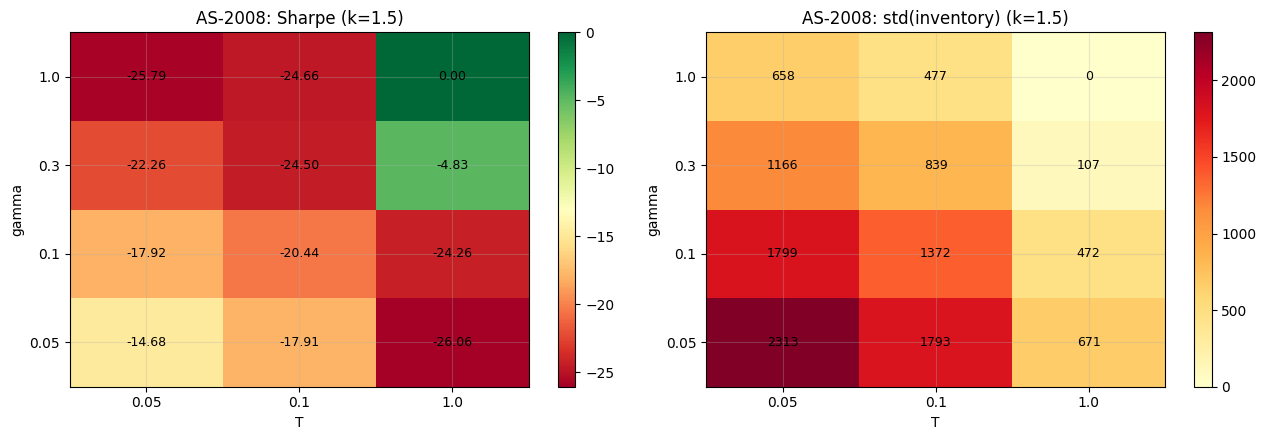

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

p_sharpe = sweep_as[sweep_as['k'] == 1.5].pivot(index='gamma', columns='T', values='sharpe')
p_inv    = sweep_as[sweep_as['k'] == 1.5].pivot(index='gamma', columns='T', values='std_inv')

for ax, p, title, cmap in [(axes[0], p_sharpe, 'Sharpe', 'RdYlGn'),
                            (axes[1], p_inv,    'std(inventory)', 'YlOrRd')]:
    im = ax.imshow(p.values, aspect='auto', cmap=cmap, origin='lower')
    ax.set_xticks(range(len(p.columns))); ax.set_xticklabels(p.columns)
    ax.set_yticks(range(len(p.index))); ax.set_yticklabels(p.index)
    ax.set_xlabel('T'); ax.set_ylabel('gamma'); ax.set_title(f'AS-2008: {title} (k=1.5)')
    for ii in range(p.shape[0]):
        for jj in range(p.shape[1]):
            v = p.values[ii, jj]
            ax.text(jj, ii, f'{v:.2f}' if title == 'Sharpe' else f'{v:.0f}',
                    ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)

plt.tight_layout(); plt.show()

Heatmap'ы показывают структуру параметрического пространства AS:
- **Зелёные ячейки** в Sharpe — лучшие конфиги.
- **Красные ячейки** в std(inv) — большие позиции (плохо).
- Видна "седловина": слишком маленькие γ·T → плохой контроль; слишком большие → стратегия выпадает из стакана.

---
## 4. Что меняется когда мы меняем γ?

γ — risk aversion. Чем больше γ, тем сильнее стратегия "боится" inventory.

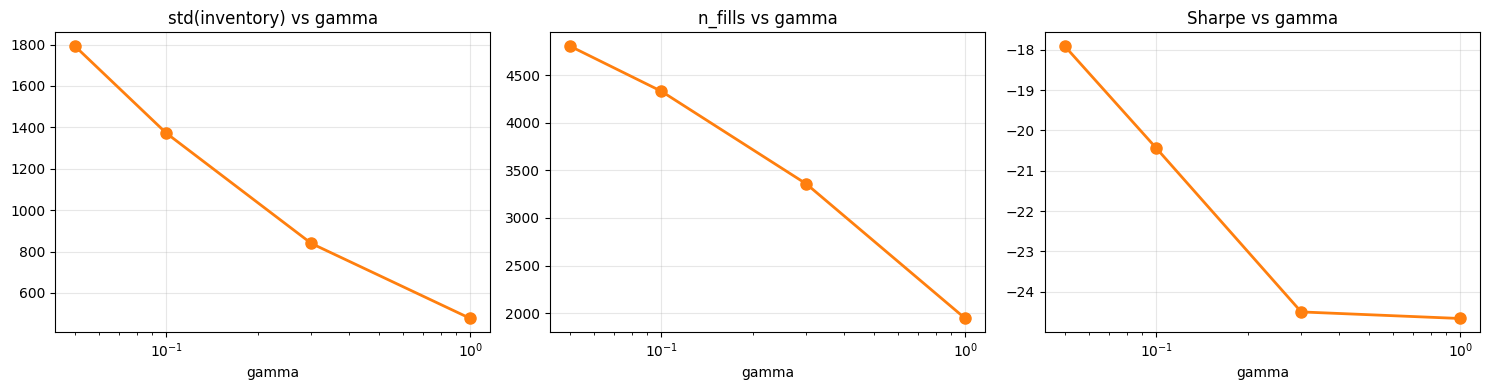

In [11]:
# Зависимость метрик AS от gamma при фиксированных T, k
filt = sweep_as[(sweep_as['T'] == 0.1) & (sweep_as['k'] == 1.5)].sort_values('gamma')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['std_inv', 'fills', 'sharpe'],
                           ['std(inventory)', 'n_fills', 'Sharpe']):
    ax.plot(filt['gamma'], filt[col], 'o-', color='tab:orange', lw=2, ms=8)
    ax.set_xscale('log'); ax.set_xlabel('gamma'); ax.set_title(f'{title} vs gamma')
plt.tight_layout(); plt.show()

**Чёткие закономерности:**

- `std(inv)` **падает** монотонно с ростом γ — больше боимся → жёстче держим позицию.
- `n_fills` тоже **падает** — при большом γ инвентарь сильно сдвигает котировки → одна сторона часто отключается.
- `Sharpe` имеет **оптимум в середине** — слишком маленький γ не контролирует риск, слишком большой убивает торговлю.

---
## 5. Что меняется когда мы меняем T?

T — горизонт планирования (rolling). Чем больше T, тем "дальше смотрит" стратегия.

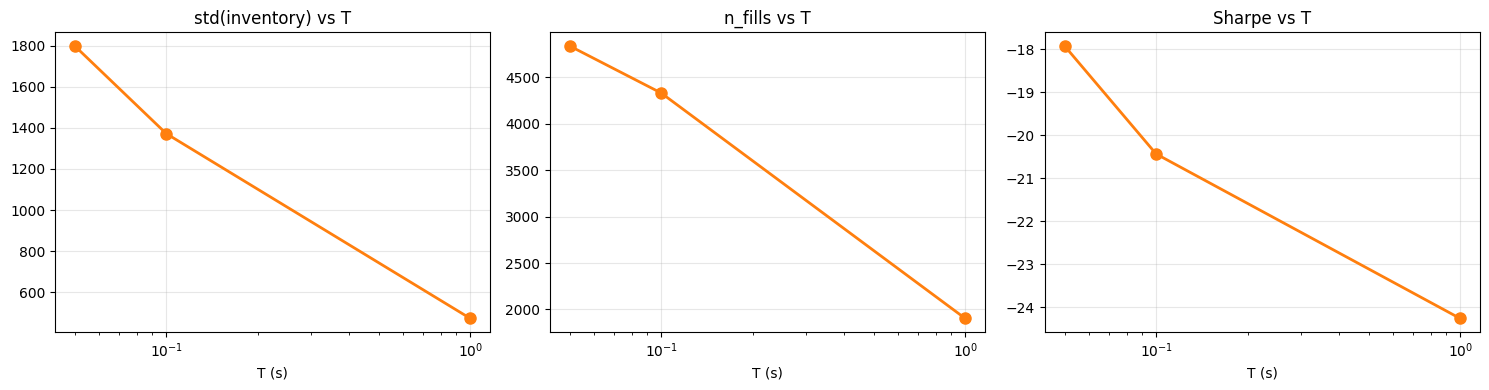

In [12]:
# Зависимость метрик AS от T при фиксированных gamma, k
filt = sweep_as[(sweep_as['gamma'] == 0.1) & (sweep_as['k'] == 1.5)].sort_values('T')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes, ['std_inv', 'fills', 'sharpe'],
                           ['std(inventory)', 'n_fills', 'Sharpe']):
    ax.plot(filt['T'], filt[col], 'o-', color='tab:orange', lw=2, ms=8)
    ax.set_xscale('log'); ax.set_xlabel('T (s)'); ax.set_title(f'{title} vs T')
plt.tight_layout(); plt.show()

**T работает аналогично γ** — в формуле они входят произведением `γ·σ²·T`. Большой T = больше боязнь = жёстче держим позицию = меньше fills.

---
## 6. Финальный выбор параметров

Берём top по Sharpe среди торгующих:

In [13]:
# Берём лучшую конфигурацию AS (топ по Sharpe) и применяем её к microprice тоже
best = sweep_as[sweep_as['fills'] >= 50].sort_values('sharpe', ascending=False).iloc[0]
print(f'Best AS config: gamma={best["gamma"]}, T={best["T"]}, k={best["k"]}')

cfg_best = StrategyConfig(gamma=best['gamma'], k=best['k'], sigma=SIGMA_FP,
                           T=best['T'], order_size=1000.0, max_inventory=20.0)

results_final = {
    'as2008':     run(AvellanedaStoikov2008(cfg_best)),
    'microprice': run(make_microprice_strategy(cfg_best)),
}

final = pd.DataFrame([with_sharpe(n, m) for n, m in results_final.items()])
final[['strategy', 'PnL', 'sharpe', 'std(inv)', 'std(dPnL)', 'max_dd', 'fills']]

Best AS config: gamma=0.3, T=1.0, k=1.5


,strategy,PnL,sharpe,std(inv),std(dPnL),max_dd,fills
0,as2008,-0.0929,-4.829892,106.704121,0.000347,-0.0929,104
1,microprice,-0.0929,-4.815983,109.698628,0.000348,-0.0929,98


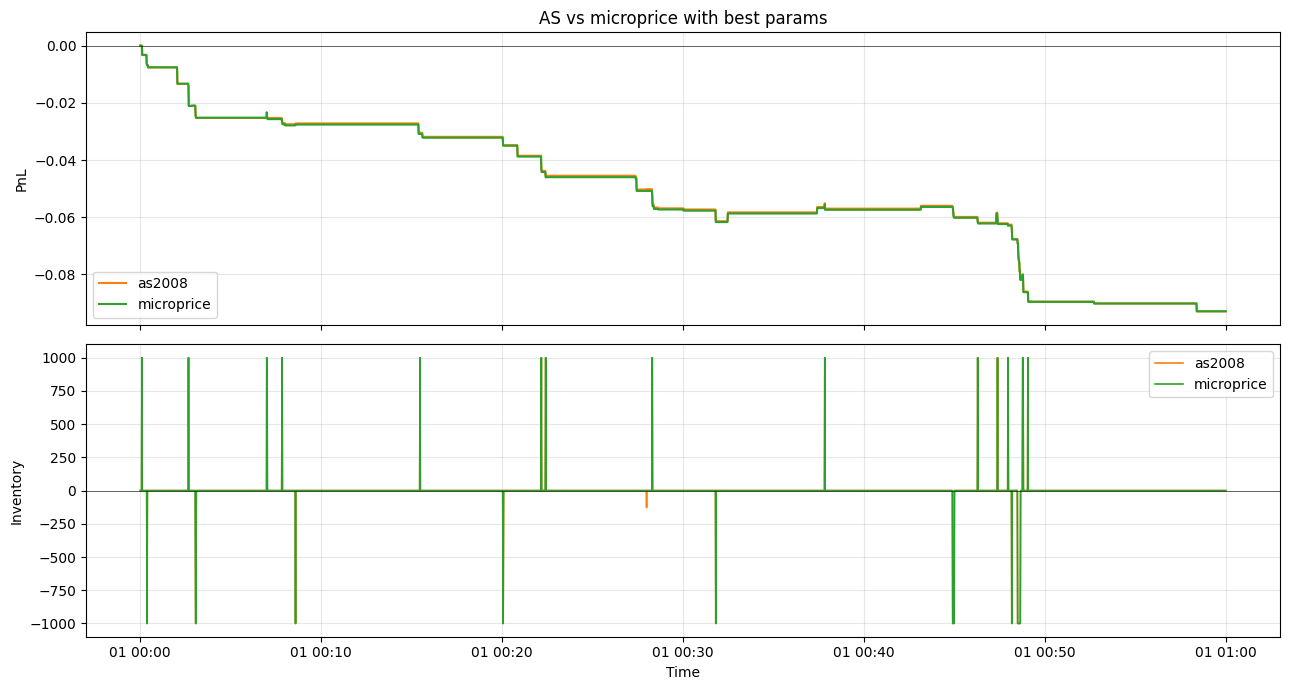

In [14]:
# Финальный график для AS и microprice
dfs_final = {n: to_df(m) for n, m in results_final.items()}

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for n, df in dfs_final.items():
    axes[0].plot(df.index, df['pnl'], label=n, color=colors[n], lw=1.5)
    axes[1].plot(df.index, df['inventory'], label=n, color=colors[n], lw=1.2)
axes[0].set_title(f'AS vs microprice with best params')
axes[0].set_ylabel('PnL'); axes[0].legend(); axes[0].axhline(0, color='black', lw=0.4)
axes[1].set_ylabel('Inventory'); axes[1].legend(); axes[1].axhline(0, color='black', lw=0.4)
axes[1].set_xlabel('Time')
plt.tight_layout(); plt.show()

## Выводы

1. **PnL у baseline сильно зависит от движения рынка.** Он не делает market-making, а держит большую направленную позицию -> PnL = inventory * (изменение цены). Куда дёрнется рынок - туда и пойдёт PnL. Модуль PnL у baseline всегда больше чем у AS, но это не альфа, а directional exposure.

2. **AS и microprice** на этой выборке практически одинаковы. На крипто-стакане imbalance не даёт большого преимущества microprice'у над mid'ом - стакан плотный, microprice почти всегда равен mid.

3. **gamma и T работают вместе** через произведение gamma * sigma^2 * T. Heatmap'ы показывают, что они взаимозаменяемы в контроле риска. Можно увеличить gamma или T - эффект похожий.

4. **Sharpe имеет оптимум в середине** по gamma. Слишком маленький - нет inventory control. Слишком большой - стратегия отключает одну сторону, мало fills, мало торгуем.

5. **Look-ahead caveat.** Параметры подобраны на тех же данных где тестируем - оверфит. Для production нужно train/test split и rolling-sigma оценка вместо одной константы.